In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as colors
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from matplotlib import rc
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.cm
import copy
import os
import Prepare
from Prepare import Neutral, SOLPS

casepath = "/data/leuven/379/vsc37950/nt/"
SOLPSpath = "case_input/2MW-5e19/"
case1 = "Outputfile/59012392/"
case2 = "Outputfile/59012401/"
outpath1 = case1 + "data/"
outpath2 = case2 + "data/"
wallpath = casepath + SOLPSpath + "shapedata/wall.txt"
vol_2D = np.loadtxt(fname=casepath + SOLPSpath + "2D_data/vol_2D.dat", skiprows=1)
vol_2D = np.transpose(vol_2D[:, 3].reshape(38, 98))

wall = np.loadtxt(wallpath, skiprows=1)
com_rm = np.load(file=casepath + SOLPSpath + "shapedata/com_rm.npy")
com_zm = np.load(file=casepath + SOLPSpath + "shapedata/com_zm.npy")
x = range(1, 37)
y = range(1, 97)
rs_l = np.loadtxt(fname=casepath + SOLPSpath + "profiles_data/recycled_neutral_flux_D_l.data", skiprows=1)
rs_r = np.loadtxt(fname=casepath + SOLPSpath + "profiles_data/recycled_neutral_flux_D_r.data", skiprows=1)
x_l = [i * 100 for i in rs_l[:, 0]]
x_r = [i * 100 for i in rs_r[:, 0]]

lp_l = [np.sqrt(pow(com_rm[i,19,1] - com_rm[i,19,0], 2) + pow(com_zm[i,19,1] - com_zm[i,19,0], 2)) for i in range(25)]
lp_r = [np.sqrt(pow(com_rm[96 - i,19,1] - com_rm[96 - i,19,0], 2) + pow(com_zm[96 - i,19,1] - com_zm[96 - i,19,0], 2)) for i in range(25)]
dp_l = [sum(lp_l[0:i - 1]) + 0.5 * lp_l[i] for i in range(1,25)]
dp_r = [sum(lp_r[0:i - 1]) + 0.5 * lp_r[i] for i in range(1,25)]

xlim_EAST = [1.30, 1.80]
ylim_EAST = [-1.12, -0.60]
scan_EAST = [3.2e19, 3.6e19, 4e19, 4.6e19, 5e19, 5.4e19, 5.5e19, 5.6e19, 5.8e19]
scan_EAST_str = ["3.2e19", "3.6e19", "4e19", "4.6e19", "5e19", "5.4e19", "5.5e19", "5.6e19", "5.8e19"]
Legend_EAST = ["3.2e19", "3.6e19", "4e19", "4.6e19", "5e19", "5.8e19"]
Neutralcase_Tri = ["59012388/", "59012389/", "59012390/", "59012391/", "59012392/", "59012393/", "59012394/", "59012395/", "59012396/"]
Neutralcase_Ori = ["59012397/", "59012398/", "59012399/", "59012400/", "59012401/", "59012402/", "59012403/", "59012404/", "59012405/"]

caseused = [0, 4, 8]
allcases = range(9)
legend_array = ["$T_e < 0.5 eV$", "$0.5 eV <= T_e < 1 eV$", "$1 eV <= T_e < 2 eV$", "$2 eV <= T_e < 5 eV$", "$5 eV <= T_e < 10 eV$", "$T_e >= 10 eV$"]

Tri_1 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[0], 0)
Tri_2 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[1], 0)
Tri_3 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[2], 0)
Tri_4 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[3], 0)
Tri_5 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[4], 0)
Tri_6 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[5], 0)
Tri_7 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[6], 0)
Tri_8 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[7], 0)
Tri_9 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[8], 0)

Ori_1 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Ori[0], 0)
Ori_2 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Ori[1], 0)
Ori_3 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Ori[2], 0)
Ori_4 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Ori[3], 0)
Ori_5 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Ori[4], 0)
Ori_6 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Ori[5], 0)
Ori_7 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Ori[6], 0)
Ori_8 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Ori[7], 0)
Ori_9 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Ori[8], 0)

EAST_SOLPS_1 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-3.2e19/", 0)
EAST_SOLPS_2 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-3.6e19/", 0)
EAST_SOLPS_3 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-4e19/", 0)
EAST_SOLPS_4 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-4.6e19/", 0)
EAST_SOLPS_5 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5e19/", 0)
EAST_SOLPS_6 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5.4e19/", 0)
EAST_SOLPS_7 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5.5e19/", 0)
EAST_SOLPS_8 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5.6e19/", 0)
EAST_SOLPS_9 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5.8e19/", 0)

EAST_SOLPS = [EAST_SOLPS_1, EAST_SOLPS_2, EAST_SOLPS_3, EAST_SOLPS_4, EAST_SOLPS_5, EAST_SOLPS_6, EAST_SOLPS_7, EAST_SOLPS_8, EAST_SOLPS_9]
EAST = [Tri_1, Tri_2, Tri_3, Tri_4, Tri_5, Tri_6, Tri_7, Tri_8, Tri_9]

for i in range(9):
    EAST_SOLPS[i].SOLPSread()
    EAST[i].Neuread()
    EAST[i].SOLPSMu(EAST_SOLPS[i])
    EAST_SOLPS[i].Te_matrix_cal()
    #EAST[i].Smu_array(EAST_SOLPS[i])
    EAST[i].Smu_fix(EAST_SOLPS[i])
    EAST[i].Smu_sum()

save_figures_path = "/data/leuven/379/vsc37950/nt/triangle/EAST/fig/"
if not os.path.exists(save_figures_path):
    os.makedirs(save_figures_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


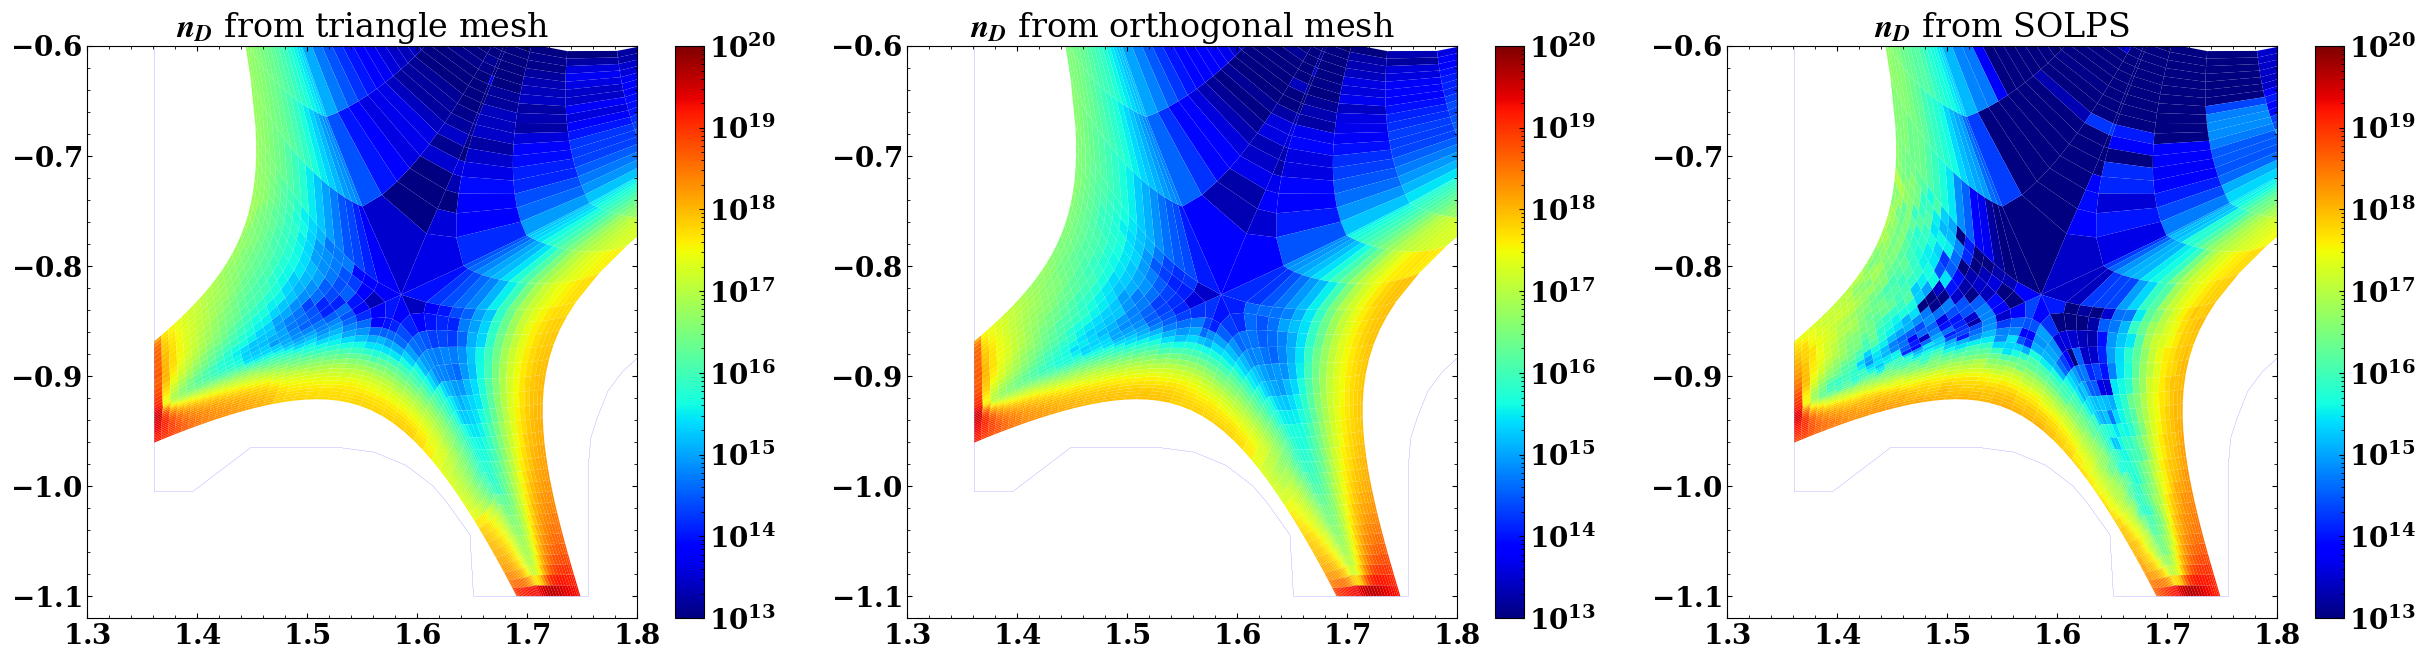

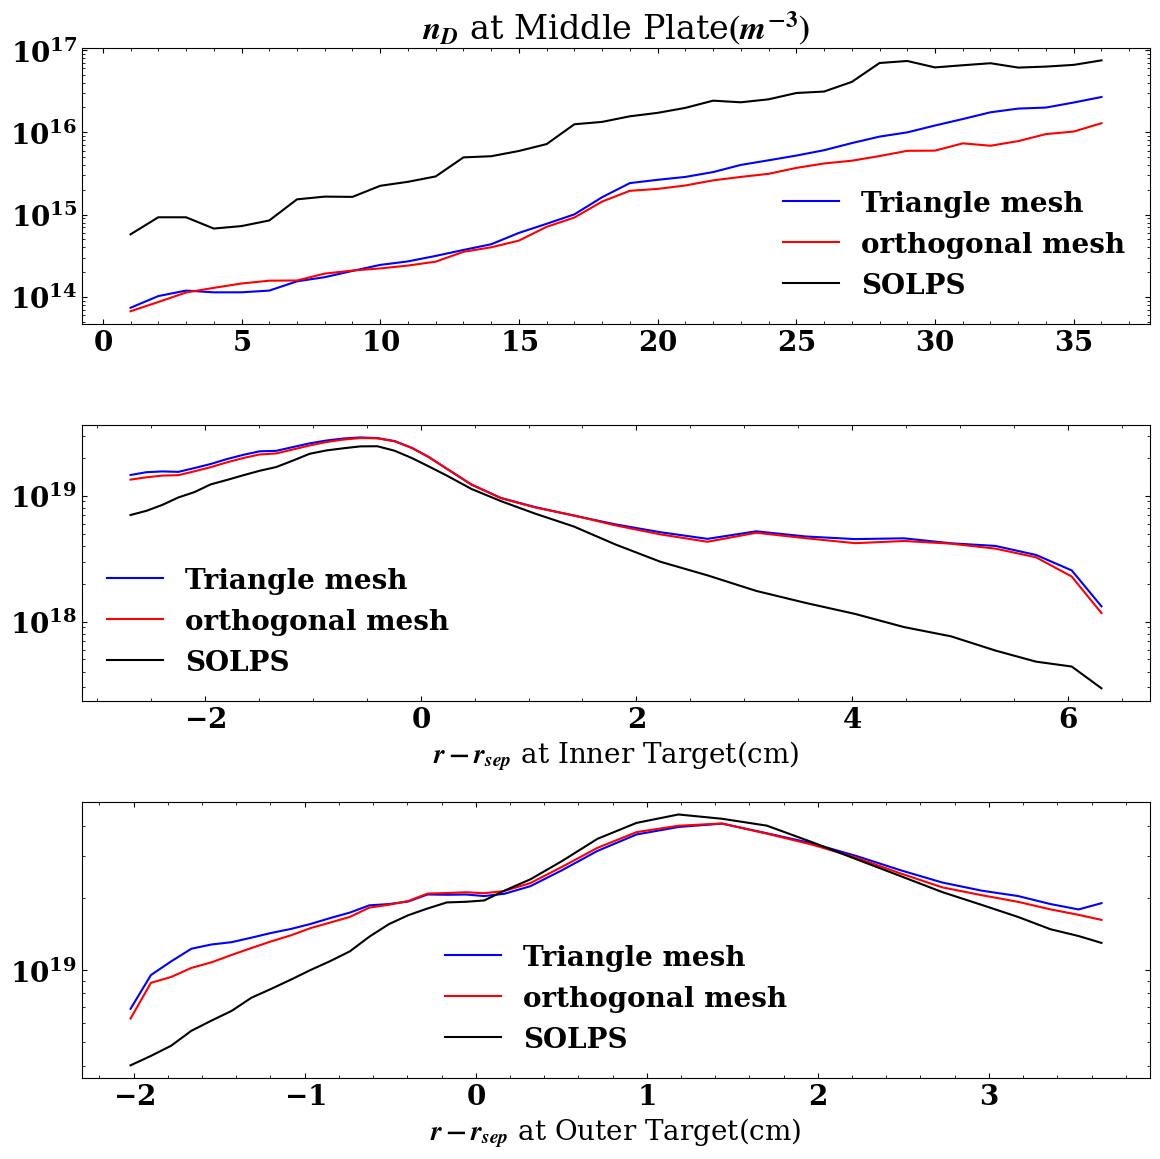

In [ ]:


value_2D = "n_D_0"
n_D_Tri = np.loadtxt(fname=casepath + outpath1 + value_2D)
n_D_old = np.loadtxt(fname=casepath + outpath2 + value_2D)
n_D_SOLPS = np.loadtxt(fname=casepath + SOLPSpath + "2D_data/nDatom_2D.data", skiprows=1)
n_D_SOLPS = np.transpose(n_D_SOLPS[:, 3].reshape(38, 98))

patches = []
ixs = 1
com_nx = 96
com_ny = 36
ixe = com_nx+1
iys = 1
iye = com_ny+1
for iy in np.arange(iys, iye):
    for ix in np.arange(ixs, ixe):
        rcol = com_rm[ix, iy, [1, 2, 4, 3]]
        zcol = com_zm[ix, iy, [1, 2, 4, 3]]
        rcol.shape = (4, 1)
        zcol.shape = (4, 1)
        polygon = Polygon(np.column_stack((rcol, zcol)), closed=True)
        patches.append(polygon)

vals1 = np.zeros((ixe-ixs)*(iye-iys))
vals2 = np.zeros((ixe-ixs)*(iye-iys))
vals3 = np.zeros((ixe-ixs)*(iye-iys))

# var2 = var2.reshape(98, 38)

for iy in np.arange(iys, iye):
    for ix in np.arange(ixs, ixe):
        k = (ix-ixs)+(ixe-ixs)*(iy-iys)
        vals1[k] = n_D_Tri[ix, iy]
        vals2[k] = n_D_old[ix, iy]
        vals3[k] = n_D_SOLPS[ix, iy]

p1 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p1.set_array(np.array(vals1))

p2 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p2.set_array(np.array(vals2))

p3 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p3.set_array(np.array(vals3))

# fig,ax = plt.subplots(1)
# fig = plt.figure(figsize=(12,3),dpi = 200)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(25, 7))
ax[0].add_collection(p1)
ax[0].autoscale_view()
ax[0].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_title("${n}_{D}$ from triangle mesh", )
ax[0].set_xlim(1.30, 1.80)
ax[0].set_ylim(-1.12, -0.60)
# ax[0].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_NeuTran), size=20)
p1.set_clim([1e13, 1e20])
# position = fig.add_axes([0.92, 0.12, 0.015, 0.78])

ax[1].add_collection(p2)
ax[1].autoscale_view()
ax[1].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_title("${n}_{D}$ from orthogonal mesh")
ax[1].set_xlim(1.30, 1.80)
ax[1].set_ylim(-1.12, -0.60)
# ax[1].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_SOLPS), size=20)
p2.set_clim([1e13, 1e20])

ax[2].add_collection(p3)
ax[2].autoscale_view()
ax[2].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_title("${n}_{D}$ from SOLPS")
ax[2].set_xlim(1.30, 1.80)
ax[2].set_ylim(-1.12, -0.60)
# ax[2].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_SOLPS), size=20)
p3.set_clim([1e13, 1e20])

fig.colorbar(p1, ax=ax[0])
fig.colorbar(p2, ax=ax[1])
fig.colorbar(p3, ax=ax[2])
# position = fig.add_axes([0.92, 0.12, 0.015, 0.78])
# cd = ax[0].colorbar(p1)
# plt.show()
#fig.savefig("fig/nD_comparison.pdf", dpi=300, bbox_inches='tight')

# Target n_D plot
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))
ax[0].semilogy(x, n_D_Tri[63, 1:37], color="b", lw=1.5)
ax[0].semilogy(x, n_D_old[63, 1:37], color="r", lw=1.5)
ax[0].semilogy(x, n_D_SOLPS[63, 1:37], color="k", lw=1.5)
ax[0].set_title("${n}_{D}$ at Middle Plate$({m}^{-3})$")
ax[0].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')

ax[1].semilogy(x_l[1:37], n_D_Tri[1, 1:37], color="b", lw=1.5)
ax[1].semilogy(x_l[1:37], n_D_old[1, 1:37], color="r", lw=1.5)
ax[1].semilogy(x_l[1:37], n_D_SOLPS[1, 1:37], color="k", lw=1.5)
# ax[1].set_title("${n}_{D}$ at Inner Targrt$({m}^{-3})$")
ax[1].set_xlabel("${r-r}_{sep}$ at Inner Target(cm)")
ax[1].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')

ax[2].semilogy(x_r[1:37], n_D_Tri[96, 1:37], color="b", lw=1.5)
ax[2].semilogy(x_r[1:37], n_D_old[96, 1:37], color="r", lw=1.5)
ax[2].semilogy(x_r[1:37], n_D_SOLPS[96, 1:37], color="k", lw=1.5)
# ax[2].set_title("${n}_{D}$ at Outer Targrt$({m}^{-3})$")
ax[2].set_xlabel("${r-r}_{sep}$ at Outer Target(cm)")
ax[2].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')
#fig.savefig("fig/nD_comparison_line.pdf", dpi=300, bbox_inches='tight')

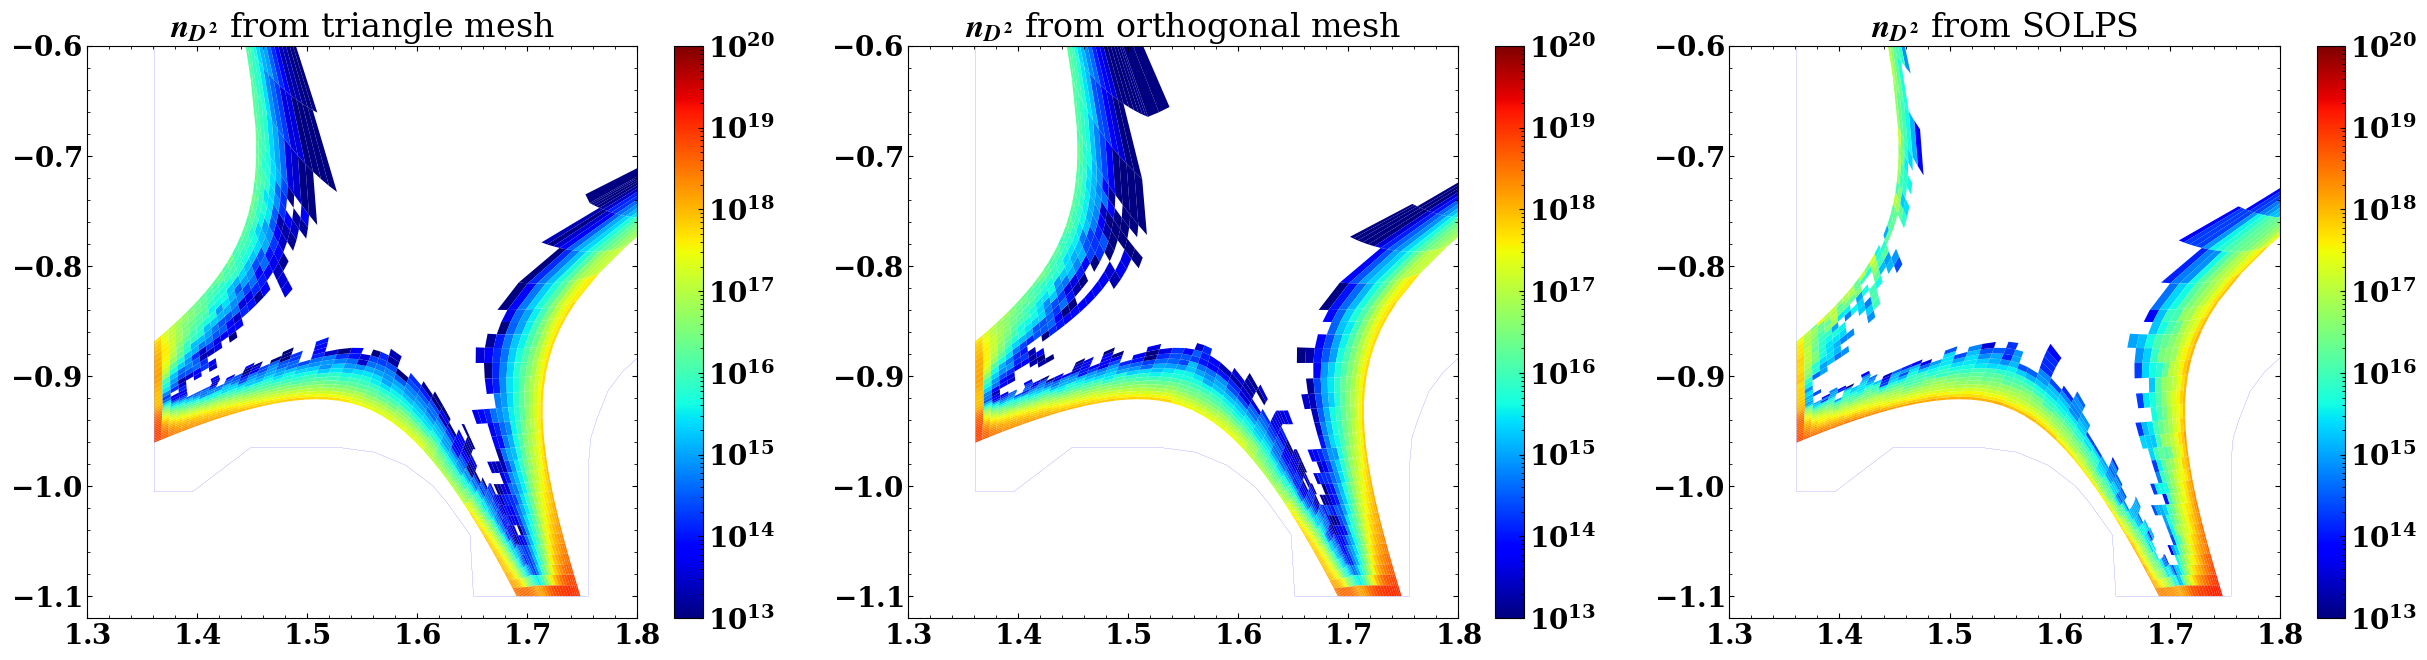

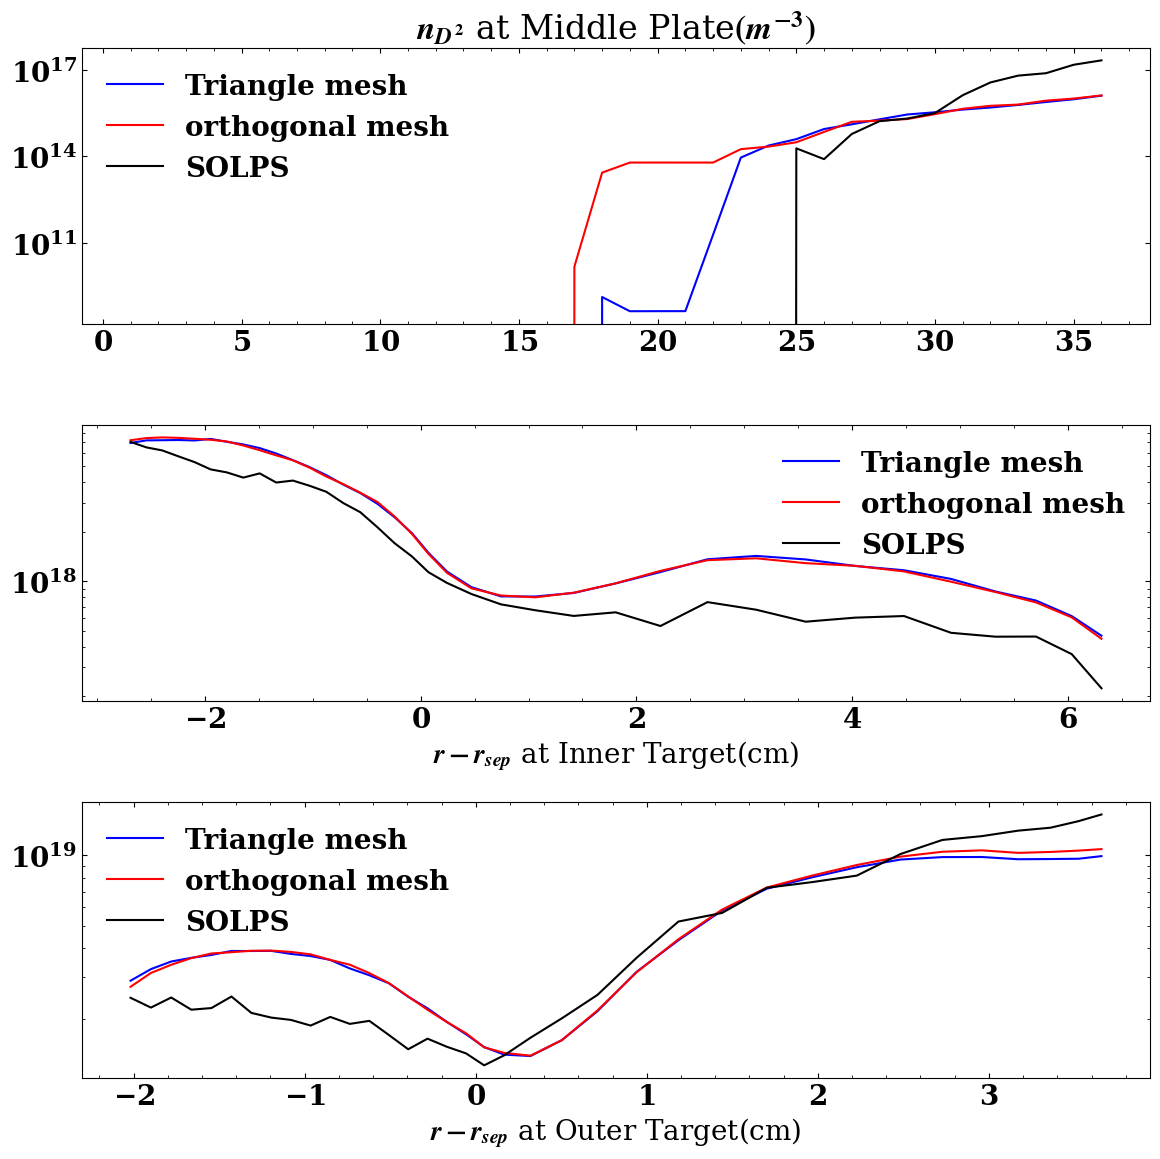

In [ ]:


value_2D = "n_D2_0"
n_D_SOLPS = np.loadtxt(fname=casepath + SOLPSpath + "2D_data/nDmolecule_2D.data", skiprows=1)
n_D_Tri = np.loadtxt(fname=casepath + outpath1 + value_2D)
n_D_old = np.loadtxt(fname=casepath + outpath2 + value_2D)
n_D_SOLPS = np.transpose(n_D_SOLPS[:, 3].reshape(38, 98))

patches = []
ixs = 1
com_nx = 96
com_ny = 36
ixe = com_nx+1
iys = 1
iye = com_ny+1
for iy in np.arange(iys, iye):
    for ix in np.arange(ixs, ixe):
        rcol = com_rm[ix, iy, [1, 2, 4, 3]]
        zcol = com_zm[ix, iy, [1, 2, 4, 3]]
        rcol.shape = (4, 1)
        zcol.shape = (4, 1)
        polygon = Polygon(np.column_stack((rcol, zcol)), closed=True)
        patches.append(polygon)

vals1 = np.zeros((ixe-ixs)*(iye-iys))
vals2 = np.zeros((ixe-ixs)*(iye-iys))
vals3 = np.zeros((ixe-ixs)*(iye-iys))

# var2 = var2.reshape(98, 38)

for iy in np.arange(iys, iye):
    for ix in np.arange(ixs, ixe):
        k = (ix-ixs)+(ixe-ixs)*(iy-iys)
        vals1[k] = n_D_Tri[ix, iy]
        vals2[k] = n_D_old[ix, iy]
        vals3[k] = n_D_SOLPS[ix, iy]

p1 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p1.set_array(np.array(vals1))

p2 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p2.set_array(np.array(vals2))

p3 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p3.set_array(np.array(vals3))

# fig,ax = plt.subplots(1)
# fig = plt.figure(figsize=(12,3),dpi = 200)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(25, 7))
ax[0].add_collection(p1)
ax[0].autoscale_view()
ax[0].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_title("${n}_{D^2}$ from triangle mesh", )
ax[0].set_xlim(1.30, 1.80)
ax[0].set_ylim(-1.12, -0.60)
# ax[0].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_NeuTran), size=20)
p1.set_clim([1e13, 1e20])
# position = fig.add_axes([0.92, 0.12, 0.015, 0.78])

ax[1].add_collection(p2)
ax[1].autoscale_view()
ax[1].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_title("${n}_{D^2}$ from orthogonal mesh")
ax[1].set_xlim(1.30, 1.80)
ax[1].set_ylim(-1.12, -0.60)
# ax[1].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_SOLPS), size=20)
p2.set_clim([1e13, 1e20])

ax[2].add_collection(p3)
ax[2].autoscale_view()
ax[2].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_title("${n}_{D^2}$ from SOLPS")
ax[2].set_xlim(1.30, 1.80)
ax[2].set_ylim(-1.12, -0.60)
# ax[2].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_SOLPS), size=20)
p3.set_clim([1e13, 1e20])

fig.colorbar(p1, ax=ax[0])
fig.colorbar(p2, ax=ax[1])
fig.colorbar(p3, ax=ax[2])
# position = fig.add_axes([0.92, 0.12, 0.015, 0.78])
# cd = ax[0].colorbar(p1)
# plt.show()
#fig.savefig("fig/nD_comparison.pdf", dpi=300, bbox_inches='tight')

# Target n_D plot
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))
ax[0].semilogy(x, n_D_Tri[63, 1:37], color="b", lw=1.5)
ax[0].semilogy(x, n_D_old[63, 1:37], color="r", lw=1.5)
ax[0].semilogy(x, n_D_SOLPS[63, 1:37], color="k", lw=1.5)
ax[0].set_title("${n}_{D^2}$ at Middle Plate$({m}^{-3})$")
ax[0].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')

ax[1].semilogy(x_l[1:37], n_D_Tri[1, 1:37], color="b", lw=1.5)
ax[1].semilogy(x_l[1:37], n_D_old[1, 1:37], color="r", lw=1.5)
ax[1].semilogy(x_l[1:37], n_D_SOLPS[1, 1:37], color="k", lw=1.5)
# ax[1].set_title("${n}_{D}$ at Inner Targrt$({m}^{-3})$")
ax[1].set_xlabel("${r-r}_{sep}$ at Inner Target(cm)")
ax[1].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')

ax[2].semilogy(x_r[1:37], n_D_Tri[96, 1:37], color="b", lw=1.5)
ax[2].semilogy(x_r[1:37], n_D_old[96, 1:37], color="r", lw=1.5)
ax[2].semilogy(x_r[1:37], n_D_SOLPS[96, 1:37], color="k", lw=1.5)
# ax[2].set_title("${n}_{D}$ at Outer Targrt$({m}^{-3})$")
ax[2].set_xlabel("${r-r}_{sep}$ at Outer Target(cm)")
ax[2].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')
#fig.savefig("fig/nD_comparison_line.pdf", dpi=300, bbox_inches='tight')